Bath size is the full test set
Target is buoynorm normalized by log1p
x/y (x_EASE, y_EASE) normalized by maximum
Wind components (u/v_ERA5) normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
(361, 361)


C:\Users\testd\OneDrive\Bureau\McGilles\Code\RechercheMsc\src\AIce\functions.py:394: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datapd[i]=datapd[i]*stds[i]+means[i]


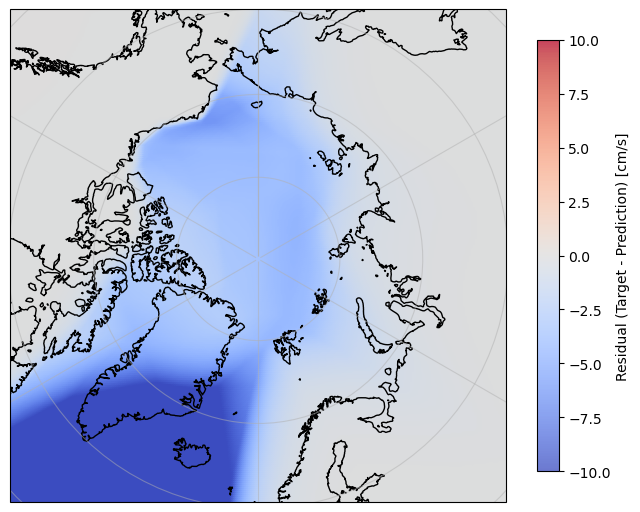

In [1]:
# Trying out to make a mesh, 
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from AIce.functions import testloader,redim,getRMSE
from  AIce.models import NNforNorms

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.colors as cm
import matplotlib as mpl

import cartopy.crs as ccrs
import cartopy.feature as cfeature


mlp256=NNforNorms(6)#['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE']

mlp256.load_state_dict(torch.load(f'../August/weights/NNforNorms_6inputs_20E_0.001lr_26-15h_42m_34s.pt', weights_only=True))# loads the weights onto the model
mlp256.eval()  # if you're doing inference, not continuing training

data,_,_,means,stds,maxes,_=testloader('../data/DRIFT_DATA_TEST.csv',['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE']
                                    ,'buoynorm',trainingset_loaded=False, training_file='../data/DRIFT_DATA_TRAIN.csv')# Get the means,stds,maxes using the longest list possible


# Making some fake fields out of curiosity. 
bath= pd.read_csv('../data/bathymetry_EASE.csv', header= None)
print(bath.shape)
datamask= (1-bath.isna()) # make sure to check where we have data
land=(bath.where(bath==3000,np.nan)-3000).to_numpy().astype(np.float32) # getting a land numpy array
landmask=bath.where(bath!=3000,np.nan)
oceanmask=(datamask*landmask)
oceanmask= oceanmask/oceanmask

nrows, ncols = bath.shape

xx, yy = np.meshgrid(np.arange(ncols), np.arange(nrows))
x_raw = xx.flatten().astype(np.float32)
y_raw = yy.flatten().astype(np.float32)

x_norm = x_raw / maxes['x_EASE']
y_norm = y_raw / maxes['y_EASE']

fakeU = np.zeros_like(x_norm)
fakeV = np.zeros_like(x_norm)
fakeh = np.full_like(x_norm, 1)
fakesic = np.full_like(x_norm, 1)

cols = ['x_EASE', 'y_EASE', 'u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas']
fakedata = pd.DataFrame(
    np.column_stack([x_norm, y_norm, fakeU, fakeV, fakesic, fakeh]),
    columns=cols
)

out = mlp256(torch.tensor(fakedata[cols].values, dtype=torch.float32)).detach().numpy()
fakedata['output'] = np.expm1(out)

# redim the physical fields only (not the coordinates — those are already raw/known)
fakedata[['u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas']] = redim(
    fakedata[['u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas']],
    means=means, stds=stds, maxes=maxes
)

# use the TRUE raw pixel indices for plotting
fakedata['x_EASE'] = x_raw
fakedata['y_EASE'] = y_raw
fakedata['null'] = np.zeros_like(x_raw)

from AIce.plotting import ResidualOnTheMap
ResidualOnTheMap(fakedata, pred='output', target='null')


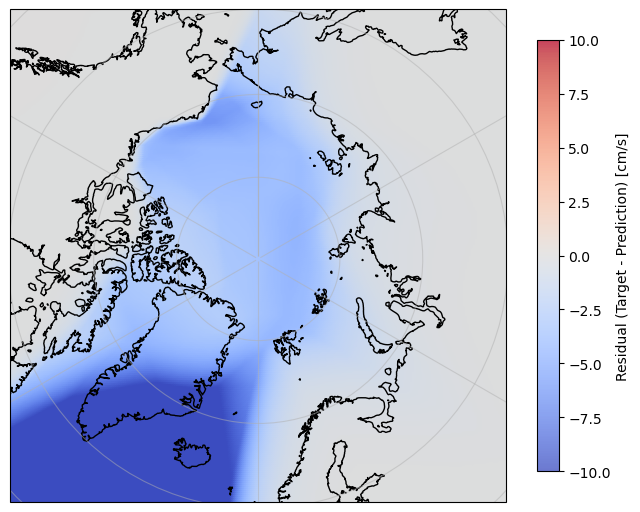

In [2]:
nrows, ncols = bath.shape  # actual EASE grid dimensions, don't hardcode 361

# raw pixel index grid, correctly oriented (row=y, col=x)
xx, yy = np.meshgrid(np.arange(ncols), np.arange(nrows))
x_raw = xx.flatten().astype(np.float32)
y_raw = yy.flatten().astype(np.float32)

# normalized inputs for the model, using the SAME normalization the model was trained with
x_norm = x_raw / maxes['x_EASE']
y_norm = y_raw / maxes['y_EASE']

fakeU = np.zeros_like(x_raw)
fakeV = np.zeros_like(x_raw)
fakeh = np.full_like(x_raw, 1)
fakesic = np.full_like(x_raw, 1)

cols = ['x_EASE', 'y_EASE', 'u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas']
fakedata = pd.DataFrame(
    np.column_stack([x_norm, y_norm, fakeU, fakeV, fakesic, fakeh]),
    columns=cols
)

out = mlp256(torch.tensor(fakedata[cols].values, dtype=torch.float32)).detach().numpy()
fakedata['output'] = np.expm1(out)

# for plotting, use the TRUE raw indices, not a redim'd reconstruction
fakedata['x_EASE'] = x_raw
fakedata['y_EASE'] = y_raw
fakedata['null'] = np.zeros_like(x_raw)

ResidualOnTheMap(fakedata, pred='output', target='null')